<a href="https://colab.research.google.com/github/Jbrr2021/A-Toyota-em-um-mercado-de-a-es-hipot-tico/blob/main/A_Toyota_em_um_mercado_de_a%C3%A7%C3%B5es_hipot%C3%A9tico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Temporal da Toyota em um Mercado de Ações Hipotético

Este projeto apresenta uma análise exploratória e temporal de um conjunto de dados da Toyota em um mercado de ações hipotético.

O objetivo é investigar o comportamento do ativo ao longo do tempo, observando preço, volume, retornos, volatilidade e indicadores técnicos como RSI, MACD e médias móveis.

## Objetivos da análise

Nesta análise, busco:

- entender a estrutura do dataset
- verificar a qualidade dos dados
- analisar o comportamento do preço de fechamento ao longo do tempo
- observar a evolução do volume negociado
- estudar a distribuição dos retornos
- comparar medidas de volatilidade
- interpretar indicadores técnicos, como RSI e MACD
- visualizar médias móveis e retorno acumulado
- identificar padrões relevantes para a série temporal

## Carregamento dos dados

Nesta etapa, o dataset é carregado no Google Colab a partir do Kaggle, utilizando a biblioteca `kagglehub`.

Em seguida, o arquivo CSV é identificado automaticamente e lido com `pandas` para posterior análise.

In [37]:
# 1. Baixar e carregar o arquivo no Colab
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("borovai0/toyota-in-a-hypothetical-stock-market")
print("Path:", path)
print("Arquivos:", os.listdir(path))

Using Colab cache for faster access to the 'toyota-in-a-hypothetical-stock-market' dataset.
Path: /kaggle/input/toyota-in-a-hypothetical-stock-market
Arquivos: ['final.csv']


In [38]:
# 2. Fazer o carregamento do CSV automaticamente

arquivos = os.listdir(path)
csvs = [arq for arq in arquivos if arq.endswith(".csv")]

arquivos_csv = os.path.join(path, csvs[0])
df = pd.read_csv(arquivos_csv)

df.head()


,Date,Close,High,Low,Open,Volume,Return,Volatility_10,Volatility_30,RSI,MACD,MACD_Signal
0,5/29/1980,2.181837,2.181837,2.181837,2.181837,0,0.000000,0.012999,0.010338,68.571347,0.063000,0.063758
1,5/30/1980,2.174467,2.203951,2.174467,2.181838,6540,-0.003378,0.013104,0.010406,65.714212,0.060108,0.063028
2,6/2/1980,2.181837,2.211321,2.181837,2.181837,934,0.003390,0.009428,0.009725,60.000000,0.057746,0.061972
3,6/3/1980,2.181837,2.211321,2.181837,2.181837,18686,0.000000,0.009266,0.009725,60.000000,0.055237,0.060625
4,6/4/1980,2.189208,2.218692,2.189208,2.189208,8409,0.003378,0.006957,0.009686,61.290296,0.053229,0.059146


## Inspeção inicial dos dados

Antes de iniciar a análise, é importante conhecer a estrutura do dataset.

Nesta etapa, verifico:

- o número de linhas e colunas
- os nomes das variáveis
- os tipos de dados
- estatísticas descritivas
- a existência de valores ausentes

In [39]:
# 3. Inspeção inicial

print(df.shape)
print(df.columns)
df.info()
print(df.describe())
print(df.isnull().sum())

(11552, 12)
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Return',
       'Volatility_10', 'Volatility_30', 'RSI', 'MACD', 'MACD_Signal'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11552 entries, 0 to 11551
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           11552 non-null  object 
 1   Close          11552 non-null  float64
 2   High           11552 non-null  float64
 3   Low            11552 non-null  float64
 4   Open           11552 non-null  float64
 5   Volume         11552 non-null  int64  
 6   Return         11552 non-null  float64
 7   Volatility_10  11552 non-null  float64
 8   Volatility_30  11552 non-null  float64
 9   RSI            11552 non-null  float64
 10  MACD           11552 non-null  float64
 11  MACD_Signal    11552 non-null  float64
dtypes: float64(10), int64(1), object(1)
memory usage: 1.1+ MB
              Close          High      

## Observações iniciais

O dataset possui 11.552 registros e 12 colunas.

Não foram encontrados valores ausentes, o que facilita a análise. Além disso, a base já inclui variáveis importantes para estudos de mercado financeiro, como:

- preços de abertura, máxima, mínima e fechamento
- volume negociado
- retorno diário
- volatilidade de 10 e 30 períodos
- RSI
- MACD
- MACD Signal

Isso torna o conjunto de dados bastante útil para treinar análise temporal e interpretação de indicadores técnicos.

## Conversão da coluna de data

A coluna `Date` foi convertida para o tipo datetime e os registros foram ordenados cronologicamente.

Esse passo é essencial em análises temporais, pois garante que os gráficos e cálculos respeitem a ordem correta dos eventos ao longo do tempo.

In [40]:
# 4. Converter data e ordenar

df ["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.head()

,Date,Close,High,Low,Open,Volume,Return,Volatility_10,Volatility_30,RSI,MACD,MACD_Signal
0,1980-05-29,2.181837,2.181837,2.181837,2.181837,0,0.000000,0.012999,0.010338,68.571347,0.063000,0.063758
1,1980-05-30,2.174467,2.203951,2.174467,2.181838,6540,-0.003378,0.013104,0.010406,65.714212,0.060108,0.063028
2,1980-06-02,2.181837,2.211321,2.181837,2.181837,934,0.003390,0.009428,0.009725,60.000000,0.057746,0.061972
3,1980-06-03,2.181837,2.211321,2.181837,2.181837,18686,0.000000,0.009266,0.009725,60.000000,0.055237,0.060625
4,1980-06-04,2.189208,2.218692,2.189208,2.189208,8409,0.003378,0.006957,0.009686,61.290296,0.053229,0.059146


## Período analisado

Após a conversão da data, foi possível verificar o intervalo temporal coberto pelo dataset.

A série se estende de 1980 até 2026, permitindo observar o comportamento do ativo em um horizonte bastante amplo de longo prazo.

In [41]:
# 5. Ver período coberto pelo dataset

print("Data inicial:", df["Date"].min())
print("Data final:", df["Date"].max())

Data inicial: 1980-05-29 00:00:00
Data final: 2026-03-30 00:00:00


## Evolução do preço de fechamento

O gráfico a seguir mostra o comportamento do preço de fechamento da Toyota ao longo do tempo.

Essa visualização permite identificar tendências de valorização, períodos de queda, correções e aumento de oscilação em determinados intervalos da série.

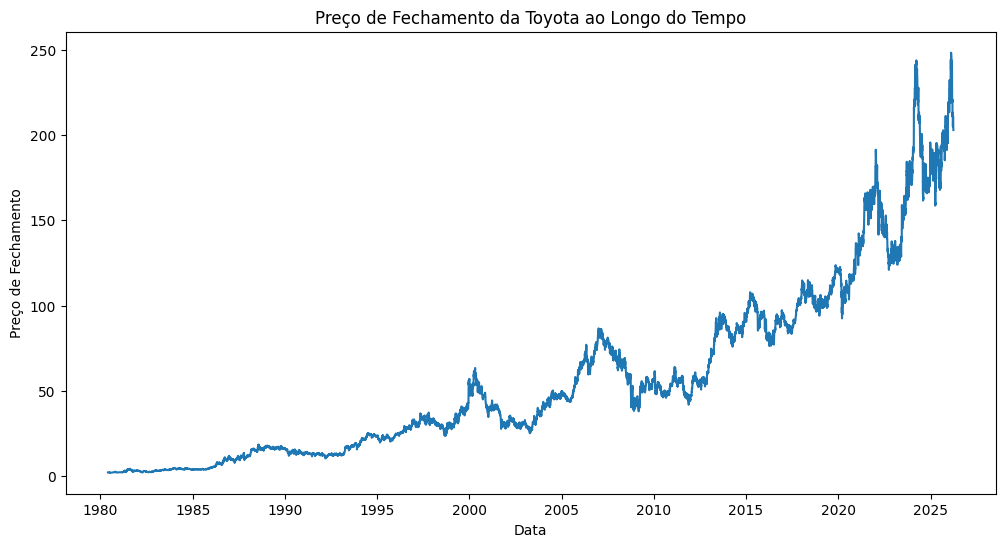

In [42]:
# 6. Gráfico do preço de fechamento

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"])
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
plt.title("Preço de Fechamento da Toyota ao Longo do Tempo")
plt.show()

## Interpretação do preço de fechamento

Observa-se uma tendência de alta no longo prazo, ainda que com períodos de correção e oscilações mais intensas em alguns momentos.

Nos anos mais recentes, os movimentos do preço se tornam mais amplos, sugerindo maior intensidade nas variações do ativo.

## Evolução do volume negociado

O volume representa a quantidade negociada do ativo ao longo do tempo.

A análise dessa variável ajuda a identificar períodos de maior participação do mercado, momentos de forte interesse dos investidores e possíveis fases de maior instabilidade.

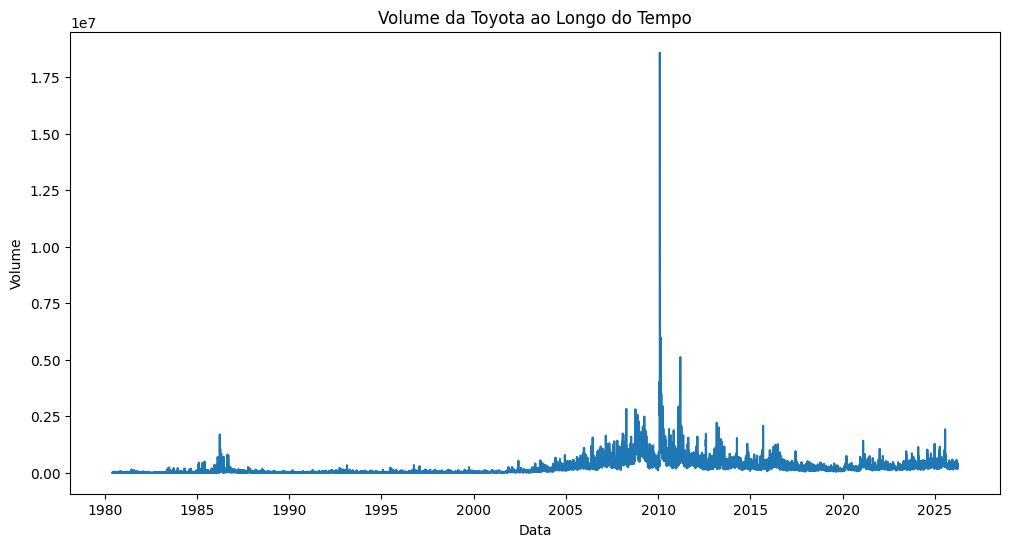

In [43]:
# 7. Gráfico do volume

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Volume"])
plt.xlabel("Data")
plt.ylabel("Volume")
plt.title("Volume da Toyota ao Longo do Tempo")
plt.show()


## Interpretação do volume

O volume apresentou picos expressivos em determinados períodos da série, indicando momentos de maior atividade de negociação.

Esses picos podem estar relacionados a fases de maior volatilidade ou mudanças mais intensas no comportamento do mercado.

## Maiores altas e maiores quedas

Os retornos diários ajudam a identificar os movimentos mais extremos da série.

Nesta etapa, são observadas a maior alta e a maior queda diária registradas no dataset, o que ajuda a destacar eventos de forte oscilação.

In [44]:
# 8. Ver maiores altas e maiores quedas

print("Maior alta diária:", df["Return"].max())
print("Maior queda diária:", df["Return"].min())

Maior alta diária: 0.19354864
Maior queda diária: -0.165235998


## Distribuição dos retornos

O histograma dos retornos permite visualizar como as variações diárias estão distribuídas.

Esse tipo de gráfico é útil para verificar:

- concentração dos retornos próximos de zero
- assimetria da distribuição
- presença de caudas
- ocorrência de movimentos extremos

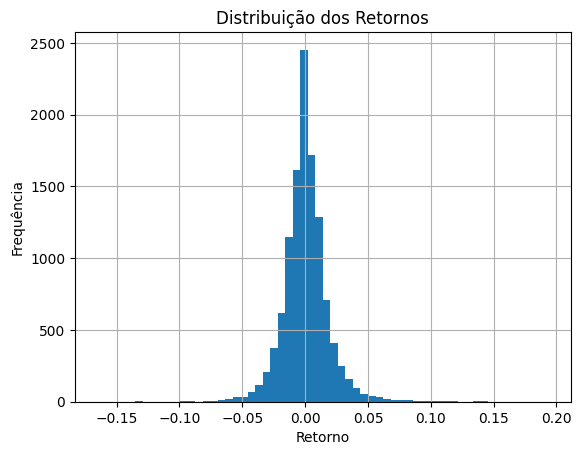

In [45]:
# 9. Histograma dos retornos

df["Return"].hist(bins=60)
plt.xlabel("Retorno")
plt.ylabel("Frequência")
plt.title("Distribuição dos Retornos")
plt.show()

## Interpretação da distribuição dos retornos

A maior parte dos retornos está concentrada próxima de zero, indicando que, na maioria dos dias, as variações foram relativamente pequenas.

No entanto, também há observações extremas positivas e negativas, o que evidencia a presença de eventos de forte oscilação ao longo da série.

## Comparação entre volatilidade de 10 e 30 períodos

A volatilidade mede a intensidade das oscilações do ativo.

Neste gráfico, são comparadas duas janelas:

- volatilidade de 10 períodos, mais sensível ao curto prazo
- volatilidade de 30 períodos, mais suave e estável

A comparação permite observar como o risco do ativo varia ao longo do tempo.

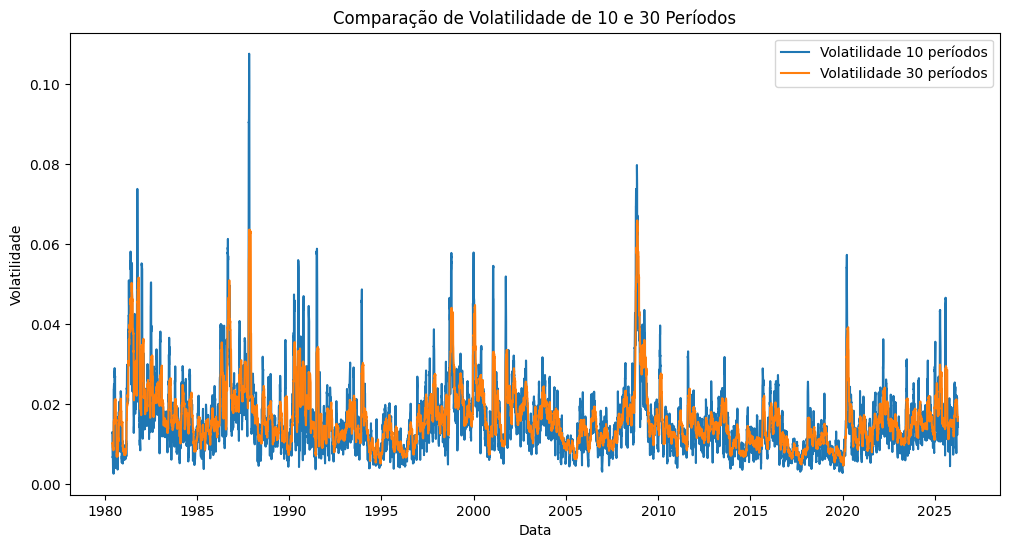

In [46]:
# 10. Comparar volatilidade de 10 e 30 períodos

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Volatility_10"], label="Volatilidade 10 períodos")
plt.plot(df["Date"], df["Volatility_30"], label="Volatilidade 30 períodos")
plt.xlabel("Data")
plt.ylabel("Volatilidade")
plt.title("Comparação de Volatilidade de 10 e 30 Períodos")
plt.legend()
plt.show()


## Interpretação da volatilidade

A volatilidade de 10 períodos reage mais rapidamente aos movimentos do mercado, enquanto a de 30 períodos apresenta comportamento mais suave.

Ambas aumentam em momentos de maior instabilidade, indicando períodos em que o ativo esteve sujeito a oscilações mais intensas.

## Índice de Força Relativa (RSI)

O RSI é um indicador técnico usado para avaliar a força dos movimentos do ativo.

De forma geral:

- valores acima de 70 podem indicar sobrecompra
- valores abaixo de 30 podem indicar sobrevenda

A análise do RSI ajuda a identificar momentos em que o preço pode estar mais esticado para cima ou para baixo.

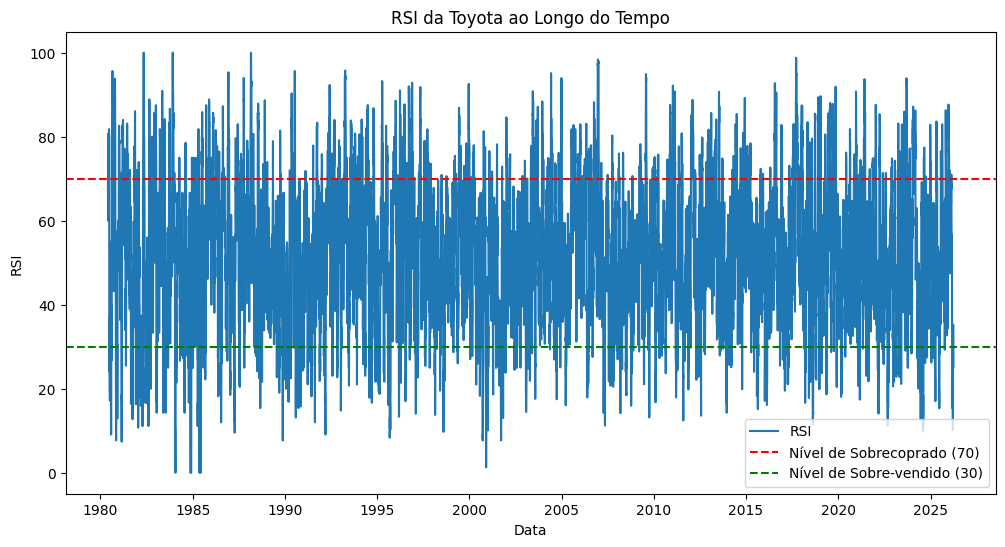

In [47]:
# 11. Analisar RSI

df_recente = df[df["Date"] >= "2020-01-01"]

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["RSI"], label="RSI")
plt.axhline(70, linestyle="--", color="red", label="Nível de Sobrecoprado (70)")
plt.axhline(30, linestyle="--", color="green", label="Nível de Sobre-vendido (30)")
plt.xlabel("Data")
plt.ylabel("RSI")
plt.title("RSI da Toyota ao Longo do Tempo")
plt.legend()
plt.show()

## Interpretação do RSI

O RSI oscilou diversas vezes entre níveis baixos e altos ao longo da série, mostrando alternância entre momentos de maior força compradora e maior pressão vendedora.

Como o período analisado é muito extenso, esse indicador pode ficar visualmente carregado. Ainda assim, ele permite perceber mudanças frequentes no equilíbrio do mercado.

## MACD e linha de sinal

O MACD é um indicador técnico utilizado para observar tendência e possíveis mudanças de direção no ativo.

Neste gráfico, são analisados:

- a linha MACD
- a linha de sinal
- a linha neutra em zero

A relação entre essas curvas ajuda a interpretar possíveis mudanças de ritmo na tendência.

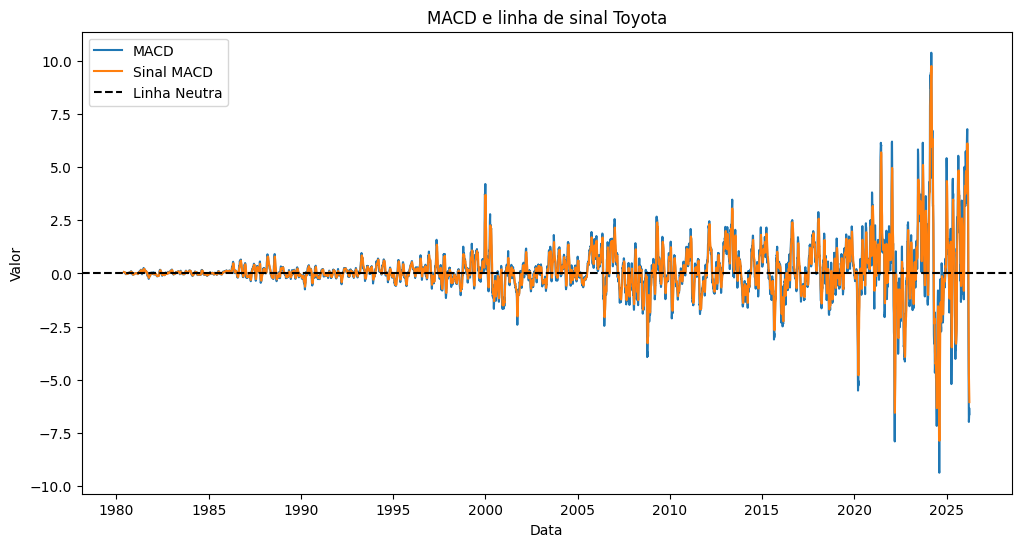

In [48]:
# 12. Analisar MACD e sinal

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["MACD"], label="MACD")
plt.plot(df["Date"], df["MACD_Signal"], label="Sinal MACD")
plt.axhline(0, linestyle="--", color="black", label="Linha Neutra")
plt.xlabel("Data")
plt.ylabel("Valor")
plt.legend()
plt.title("MACD e linha de sinal Toyota")
plt.show()



## Interpretação do MACD

O MACD e sua linha de sinal apresentaram comportamento bastante próximo ao longo do tempo, com oscilações mais intensas em alguns períodos da série.

Nos anos mais recentes, observa-se aumento na amplitude dos movimentos, sugerindo mudanças de tendência mais fortes.

## Médias móveis de 20 e 50 períodos

As médias móveis são úteis para suavizar a série de preços e facilitar a visualização da tendência principal.

Nesta etapa, são comparadas:

- média móvel de 20 períodos
- média móvel de 50 períodos

A média de 20 períodos reage mais rápido ao preço, enquanto a de 50 períodos apresenta comportamento mais suave.

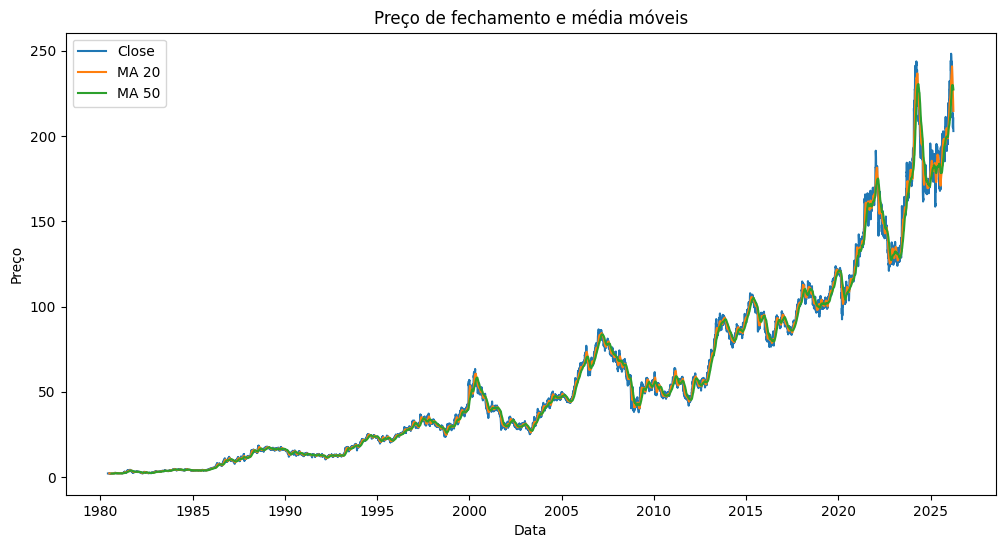

In [49]:
# 13. Criar média móveis
df["MA_20"] = df["Close"].rolling(20).mean()
df["MA_50"] = df["Close"].rolling(50).mean()

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA_20"], label="MA 20")
plt.plot(df["Date"], df["MA_50"], label="MA 50")
plt.title("Preço de fechamento e média móveis")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.legend()
plt.show()

## Interpretação das médias móveis

As médias móveis acompanharam bem a evolução do preço e ajudaram a destacar a tendência de alta no longo prazo.

A média de 20 períodos se mostrou mais sensível às oscilações, enquanto a de 50 períodos foi mais estável, contribuindo para a leitura da direção principal do ativo.

In [50]:
# 14. Ver correlação entre variáveis
df.corr(numeric_only=True)

,Close,High,Low,Open,Volume,Return,Volatility_10,Volatility_30,RSI,MACD,MACD_Signal,MA_20,MA_50
Close,1.000000,0.999967,0.999965,0.999932,0.251256,0.000711,-0.161246,-0.203904,0.038640,0.180716,0.197652,0.998472,0.996459
High,0.999967,1.000000,0.999947,0.999965,0.252609,-0.001540,-0.159860,-0.202602,0.037380,0.179227,0.196473,0.998569,0.996606
Low,0.999965,0.999947,1.000000,0.999962,0.249403,-0.001224,-0.162859,-0.205302,0.038763,0.181448,0.198262,0.998434,0.996400
Open,0.999932,0.999965,0.999962,1.000000,0.251308,-0.003637,-0.161312,-0.203896,0.037408,0.179997,0.197148,0.998534,0.996550
Volume,0.251256,0.252609,0.249403,0.251308,1.000000,-0.008721,0.095770,0.062399,-0.034954,-0.047682,-0.033268,0.254758,0.256649
Return,0.000711,-0.001540,-0.001224,-0.003637,-0.008721,1.000000,0.053694,0.029982,0.236101,0.025241,-0.010502,-0.013208,-0.013234
Volatility_10,-0.161246,-0.159860,-0.162859,-0.161312,0.095770,0.053694,1.000000,0.785159,-0.000414,-0.080922,-0.096612,-0.162806,-0.159073
Volatility_30,-0.203904,-0.202602,-0.205302,-0.203896,0.062399,0.029982,0.785159,1.000000,-0.006936,-0.056321,-0.072412,-0.206035,-0.203161
RSI,0.038640,0.037380,0.038763,0.037408,-0.034954,0.236101,-0.000414,-0.006936,1.000000,0.493112,0.353819,0.006732,-0.005714
MACD,0.180716,0.179227,0.181448,0.179997,-0.047682,0.025241,-0.080922,-0.056321,0.493112,1.000000,0.947686,0.140932,0.101257


## Matriz e mapa de correlação

A análise de correlação permite observar a força da relação linear entre as variáveis numéricas do dataset.

Ela é útil para identificar:

- quais variáveis se comportam de forma semelhante
- quais indicadores possuem relação mais forte
- quais medidas apresentam baixa associação linear

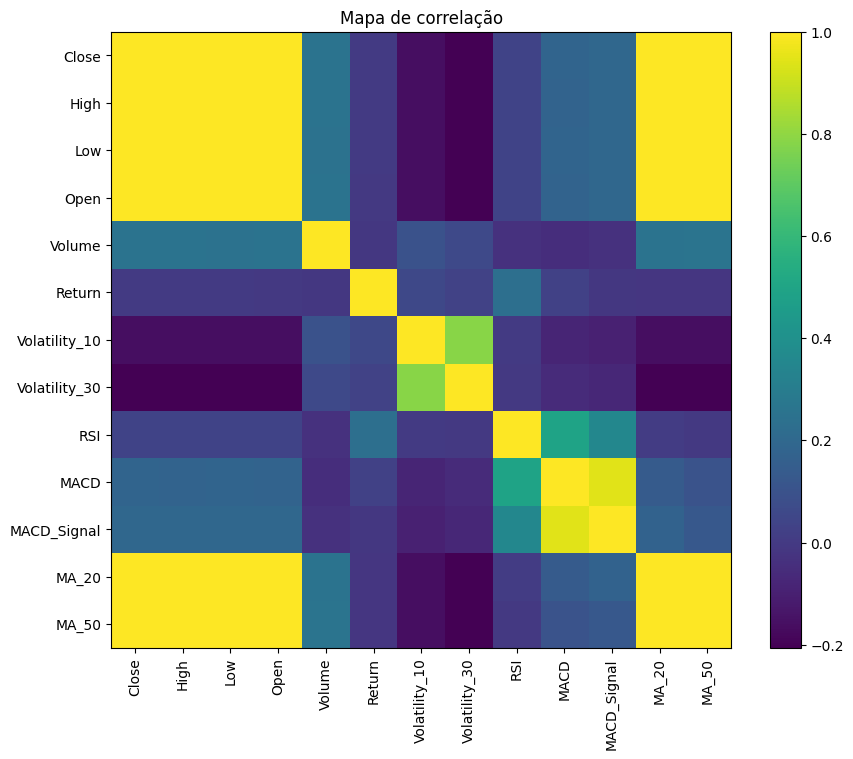

In [51]:
# 15. Heatmap da correlação

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Mapa de correlação")
plt.show()



## Interpretação da correlação

As variáveis de preço (`Open`, `High`, `Low`, `Close`) apresentaram correlação extremamente alta entre si, o que era esperado por representarem o mesmo ativo sob perspectivas muito próximas.

As médias móveis também apresentaram forte correlação com o preço de fechamento, enquanto o `MACD` e o `MACD_Signal` mostraram associação bastante elevada.

Já os retornos diários apresentaram correlação fraca com a maioria das variáveis, refletindo maior variabilidade de curto prazo.

## Retorno acumulado

O retorno acumulado mostra a evolução do investimento ao longo do tempo, considerando a composição dos retornos diários.

Essa visualização é importante para avaliar o desempenho do ativo em uma perspectiva de longo prazo.

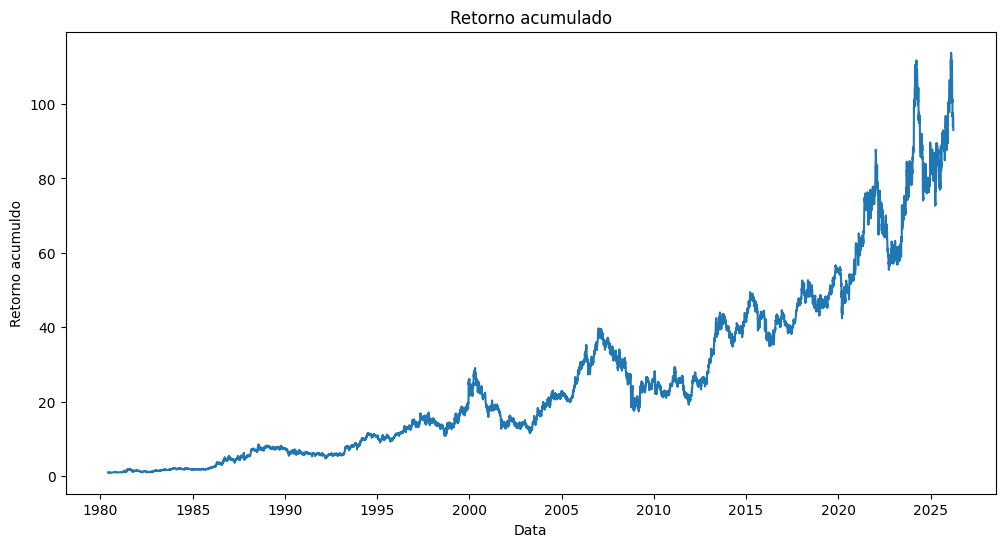

In [52]:
# 16. Retorno acumulado

df["cum_return"] = (1 + df["Return"]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["cum_return"])
plt.title("Retorno acumulado")
plt.xlabel("Data")
plt.ylabel("Retorno acumuldo")
plt.show()

## Interpretação do retorno acumulado

O gráfico de retorno acumulado evidencia valorização expressiva ao longo da série, apesar de períodos de queda e maior instabilidade em determinados momentos.

Isso sugere que, no horizonte analisado, o ativo apresentou crescimento relevante no longo prazo.

## Eventos extremos da série

Além da análise visual, também foram identificadas as datas com a maior alta e a maior queda diária do período.

Esses pontos ajudam a destacar momentos extremos da série e reforçam a presença de oscilações significativas ao longo do tempo.

In [53]:
# 17. Ver datas da maior alta e maior queda

print(df.loc[df["Return"].idxmax(), ["Date", "Return"]])
print(df.loc[df["Return"].idxmin(), ["Date", "Return"]])

Date      1987-10-21 00:00:00
Return               0.193549
Name: 1870, dtype: object
Date      2008-11-06 00:00:00
Return              -0.165236
Name: 7178, dtype: object


## Conclusão final

A análise temporal do ativo da Toyota em um mercado hipotético mostrou uma trajetória de valorização no longo prazo, acompanhada por períodos de correção e maior instabilidade.

O preço de fechamento apresentou tendência de alta ao longo das décadas, enquanto o volume negociado revelou picos relevantes em momentos específicos, indicando maior atividade do mercado.

A distribuição dos retornos mostrou forte concentração próxima de zero, mas também revelou a ocorrência de eventos extremos positivos e negativos. As medidas de volatilidade confirmaram a existência de períodos mais turbulentos, e os indicadores técnicos, como RSI e MACD, ajudaram a visualizar mudanças de força e tendência ao longo da série.

As médias móveis reforçaram a leitura de tendência do ativo, e a análise de correlação confirmou forte associação entre as variáveis de preço e entre indicadores relacionados.

De forma geral, o notebook mostra como técnicas básicas de análise exploratória e temporal podem ser usadas para compreender o comportamento de um ativo financeiro ao longo do tempo.

## Limitações da análise

Embora os resultados sejam úteis para fins de estudo, esta análise apresenta algumas limitações:

- o dataset representa um mercado hipotético
- correlação não implica causalidade
- indicadores técnicos não garantem previsão futura
- parte das visualizações de longo prazo fica bastante densa, especialmente para RSI e MACD

Ainda assim, o projeto é bastante válido para fins de aprendizado em Python, análise de dados e séries temporais.

## Próximos passos

Como continuidade do projeto, seria possível:

- analisar períodos mais curtos com maior detalhe
- aplicar modelos de previsão de séries temporais
- comparar indicadores técnicos entre diferentes janelas
- criar sinais de compra e venda com base em cruzamentos de médias móveis
- explorar novas métricas de risco e retorno